X_train 크기: (18519, 21)
y_train 크기: (18519,)
X_test 크기 (7938, 21)
y_test 크기 (7938,)


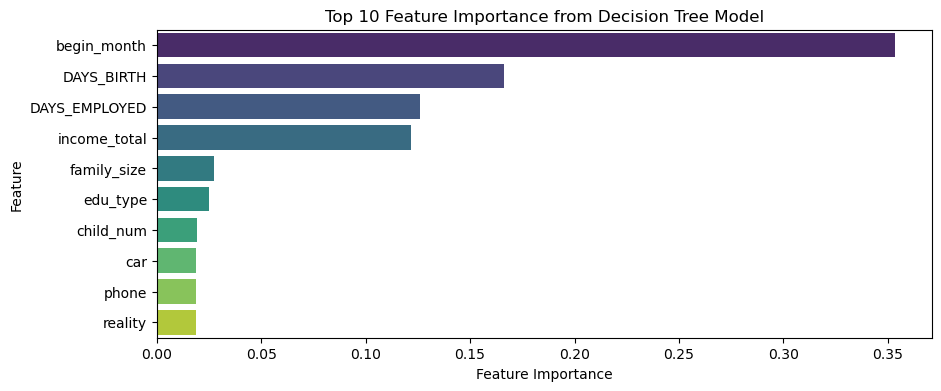

                             feature        VIF
12                       family_size  15.369027
4                          child_num  11.516631
21  guardian_status_Without Guardian   3.267065
16                occyp_group_Others   3.110626
8                      DAYS_EMPLOYED   2.553204
19             occyp_group_Technical   2.525306
7                         DAYS_BIRTH   1.883867
17                 occyp_group_Sales   1.582148
15            occyp_group_Management   1.554633
1                             gender   1.441312
18               occyp_group_Service   1.434769
9                         work_phone   1.240290
14            occyp_group_Healthcare   1.227186
2                                car   1.224014
5                       income_total   1.217583
6                           edu_type   1.198598
10                             phone   1.125945
3                            reality   1.064629
20            occyp_group_Technicala   1.054334
11                             email   1

In [7]:
#!/usr/bin/env python
# coding: utf-8

# In[1]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import seaborn as sns


# 데이터 로드
df = pd.read_csv("data2/train.csv")

# 이진 변수는 map으로 처리
df['gender'] = df['gender'].map({'F': 0, 'M': 1})
df['car'] = df['car'].map({'N': 0, 'Y': 1})
df['reality'] = df['reality'].map({'N': 0, 'Y': 1})

# 직업 변수 그룹화 및 결측값 처리
df['occyp_type'].fillna('Others', inplace=True)
job_groups = {
    'Laborers': 'Technical',
    'Managers': 'Management',
    'Sales staff': 'Sales',
    'High skill tech staff': 'Technical',
    'Core staff': 'Administrative',
    'Drivers': 'Technical',
    'Medicine staff': 'Healthcare',
    'Accountants': 'Administrative',
    'Realty agents': 'Sales',
    'Security staff': 'Service',
    'Cleaning staff': 'Service',
    'Private service staff': 'Service',
    'Cooking staff': 'Service',
    'Secretaries': 'Administrative',
    'HR staff': 'Administrative',
    'IT staff': 'Technical',
    'Low-skill Laborers': 'Technicala',
    'Waiters/barmen staff': 'Service',
    'Others': 'Others'}
df['occyp_group'] = df['occyp_type'].map(job_groups)


# edu_type 순서형 인코딩
education_order = {
    'Lower secondary': 1,
    'Secondary / secondary special': 2,
    'Incomplete higher': 3,
    'Higher education': 4,
    'Academic degree': 5}
df['edu_type'] = df['edu_type'].map(education_order)

# guardian_status 변수 생성
guardian_status = {
    'Married': 'With Guardian',
    'Civil marriage': 'With Guardian',
    'Separated': 'With Guardian',
    'Single / not married': 'Without Guardian',
    'Widow': 'Without Guardian'}
df['guardian_status'] = df['family_type'].map(guardian_status)

# 상수형 변수 제거
df.drop(columns=['FLAG_MOBIL'], inplace=True)

# income_type과 house_type 제거
df.drop(columns=['income_type', 'house_type'], inplace=True)


# 기존 family_size와 child_num 변수 제거


# 필요 시 범주형 변수에 대해 원-핫 인코딩 적용 (기준 변수는 제외)
categorical_columns = ['occyp_group', 'guardian_status']
df_encoded = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

# 피처와 타겟 변수 분리
X = df_encoded.drop(columns=['credit', 'index', 'occyp_type', 'family_type'])
y = df_encoded['credit']

# 학습 및 테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

print("X_train 크기:", X_train.shape)
print("y_train 크기:", y_train.shape)
print("X_test 크기", X_test.shape)
print("y_test 크기", y_test.shape)

# 의사결정 나무 모델 학습
model = RandomForestClassifier(random_state=0)
model.fit(X_train, y_train)

# 변수 중요도 추출
feature_importances = model.feature_importances_

# 변수 중요도를 데이터프레임으로 정리
importance_df = pd.DataFrame({'feature': X.columns, 'importance': feature_importances})
importance_df = importance_df.sort_values(by='importance', ascending=False)

# 변수 중요도 시각화 상위 10
plt.figure(figsize=(10, 4))
sns.barplot(x='importance', y='feature', data=importance_df.head(10), palette='viridis')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importance from Decision Tree Model')
plt.show()

# 변수 중요도 시각화 전체
#plt.figure(figsize=(10, 4))
#sns.barplot(x='importance', y='feature', data=importance_df, palette='viridis')
#plt.xlabel('Feature Importance')
#plt.ylabel('Feature')
#plt.title('Feature Importance from Decision Tree Model')
#plt.show()


# In[3]:


from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# 다중공선성 확인 (VIF 계산)
X_vif = add_constant(X)
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

# 상수 열 제거
vif_data = vif_data[vif_data['feature'] != 'const']
print(vif_data.sort_values(by="VIF", ascending=False))



In [1]:
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant


df = pd.read_csv("new_data.csv")

In [8]:
df["credit"].value_counts()

2.0    16968
1.0     6267
0.0     3222
Name: credit, dtype: int64

In [9]:
df2 = df[df['credit'] != 1.0]

In [10]:
df2["credit"].value_counts()

2.0    16968
0.0     3222
Name: credit, dtype: int64

In [11]:
df2

,index,gender,car,reality,child_num,income_total,edu_type,family_type,DAYS_BIRTH,DAYS_EMPLOYED,work_phone,phone,email,occyp_type,family_size,begin_month,credit,occyp_group,guardian_status
2,2,1,1,1,0,450000.0,4,Married,-19087,-4434,0,1,0,Managers,2.0,-22.0,2.0,Management,With Guardian
3,3,0,0,1,0,202500.0,2,Married,-15088,-2092,0,1,0,Sales staff,2.0,-37.0,0.0,Sales,With Guardian
4,4,0,1,1,0,157500.0,4,Married,-15037,-2105,0,0,0,Managers,2.0,-26.0,2.0,Management,With Guardian
6,6,0,0,0,0,315000.0,2,Separated,-17570,-1978,0,0,1,Core staff,1.0,-41.0,2.0,Administrative,With Guardian
7,7,1,0,1,0,270000.0,2,Married,-14896,-5420,0,0,1,Drivers,2.0,-53.0,0.0,Technical,With Guardian
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26450,26450,0,0,0,0,225000.0,2,Single / not married,-10338,-581,0,1,0,Laborers,1.0,-37.0,2.0,Technical,Without Guardian
26453,26453,0,0,1,1,180000.0,4,Separated,-15291,-2475,0,0,0,Others,2.0,-47.0,2.0,Others,With Guardian
26454,26454,0,1,0,0,292500.0,2,Civil marriage,-10082,-2015,0,0,0,Core staff,2.0,-25.0,2.0,Administrative,With Guardian
26455,26455,1,0,1,0,171000.0,3,Single / not married,-10145,-107,0,0,0,Laborers,1.0,-59.0,2.0,Technical,Without Guardian


In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 피처와 타겟 변수 분리
X = df2.drop(columns=['credit', 'index', 'occyp_type', 'family_type',])
y = df2['credit']

# 학습 및 테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# SMOTE 적용
smote = SMOTE(random_state=0)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# SMOTE 적용 전후의 클래스 분포 확인
before_counts = y_train.value_counts()
after_counts = pd.Series(y_train_smote).value_counts()

# 시각화
plt.figure(figsize=(8, 5))
plt.bar(before_counts.index.astype(str), before_counts.values, alpha=0.7, label='Before Balancing')
plt.bar(after_counts.index.astype(str), after_counts.values, alpha=0.7, label='After SMOTE Balancing')
plt.xlabel('Credit Class')
plt.ylabel('Sample Count')
plt.title('Class Distribution Before and After SMOTE')
plt.legend()
plt.show()

# X_test의 열을 학습 데이터와 동일하게 정렬
X_test = X_test[X_train_smote.columns]

# 랜덤 포레스트 모델 학습
model = RandomForestClassifier(random_state=0, n_estimators=100)
model.fit(X_train_smote, y_train_smote)

# 테스트 데이터 예측
y_pred = model.predict(X_test)

# 모델 평가
print("Classification Report:")
print(classification_report(y_test, y_pred))

# 변수 중요도 추출
feature_importances = model.feature_importances_

# 변수 중요도를 데이터프레임으로 정리
importance_df = pd.DataFrame({'feature': X.columns, 'importance': feature_importances})
importance_df = importance_df.sort_values(by='importance', ascending=False)

# 변수 중요도 시각화
plt.figure(figsize=(10, 4))
sns.barplot(x='importance', y='feature', data=importance_df, palette='viridis')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importance from Random Forest Model')
plt.show()


ValueError: could not convert string to float: 'Administrative'

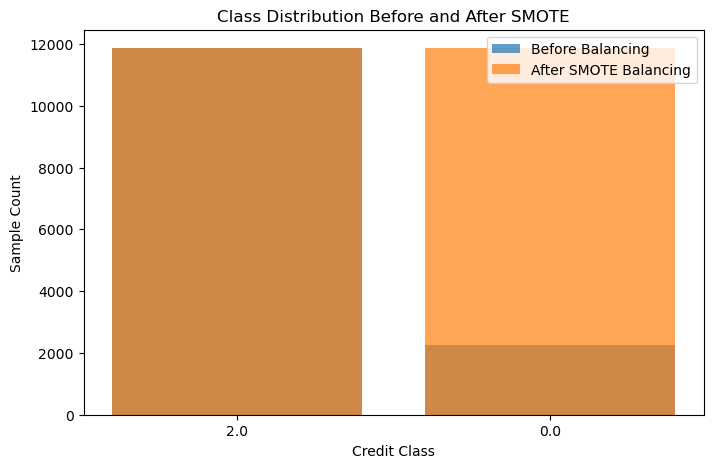

Classification Report:
              precision    recall  f1-score   support

         0.0       0.47      0.42      0.44       956
         2.0       0.89      0.91      0.90      5101

    accuracy                           0.83      6057
   macro avg       0.68      0.66      0.67      6057
weighted avg       0.83      0.83      0.83      6057



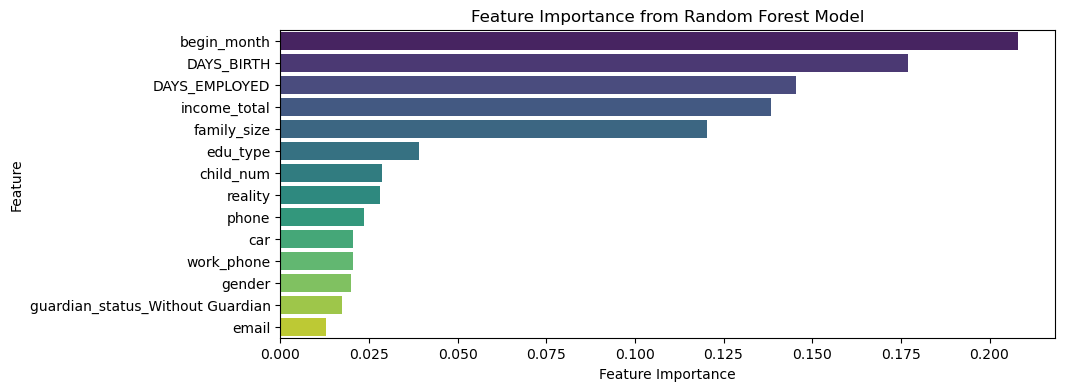

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 피처와 타겟 변수 분리
X = df2.drop(columns=['credit', 'index', 'occyp_type', 'family_type','occyp_group'])
y = df2['credit']

# 카테고리형 변수 처리 (예: 'Administrative'와 같은 문자열 변환)
X = pd.get_dummies(X, drop_first=True)  # One-Hot Encoding으로 카테고리형 변수를 처리

# 학습 및 테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# SMOTE 적용
smote = SMOTE(random_state=0)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# SMOTE 적용 전후의 클래스 분포 확인
before_counts = y_train.value_counts()
after_counts = pd.Series(y_train_smote).value_counts()

# 시각화
plt.figure(figsize=(8, 5))
plt.bar(before_counts.index.astype(str), before_counts.values, alpha=0.7, label='Before Balancing')
plt.bar(after_counts.index.astype(str), after_counts.values, alpha=0.7, label='After SMOTE Balancing')
plt.xlabel('Credit Class')
plt.ylabel('Sample Count')
plt.title('Class Distribution Before and After SMOTE')
plt.legend()
plt.show()

# X_test의 열을 학습 데이터와 동일하게 정렬
X_test = X_test[X_train_smote.columns]

# 랜덤 포레스트 모델 학습
model = RandomForestClassifier(random_state=0, n_estimators=100)
model.fit(X_train_smote, y_train_smote)

# 테스트 데이터 예측
y_pred = model.predict(X_test)

# 모델 평가
print("Classification Report:")
print(classification_report(y_test, y_pred))

# 변수 중요도 추출
feature_importances = model.feature_importances_

# 변수 중요도를 데이터프레임으로 정리
importance_df = pd.DataFrame({'feature': X.columns, 'importance': feature_importances})
importance_df = importance_df.sort_values(by='importance', ascending=False)

# 변수 중요도 시각화
plt.figure(figsize=(10, 4))
sns.barplot(x='importance', y='feature', data=importance_df, palette='viridis')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importance from Random Forest Model')
plt.show()


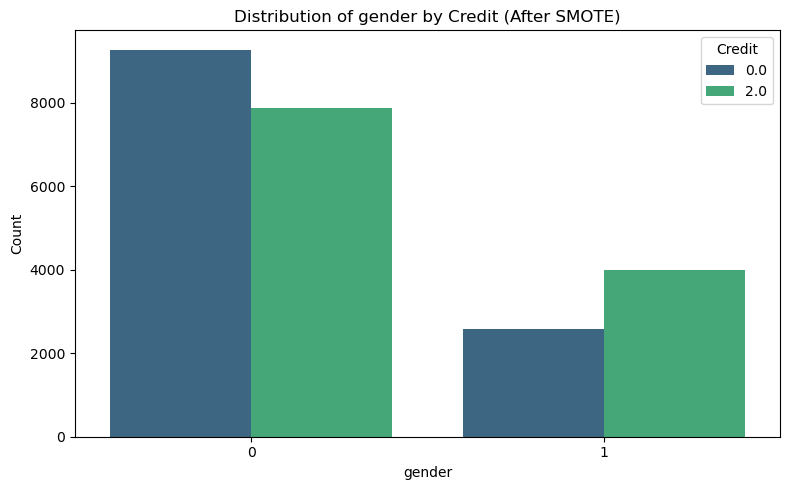

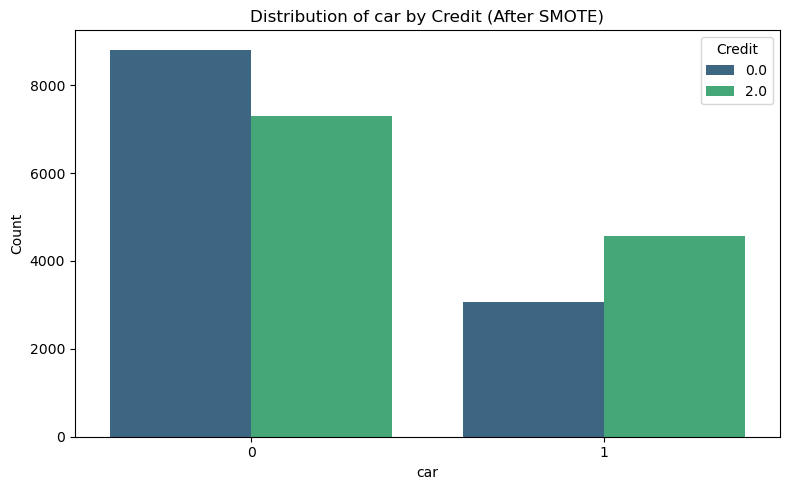

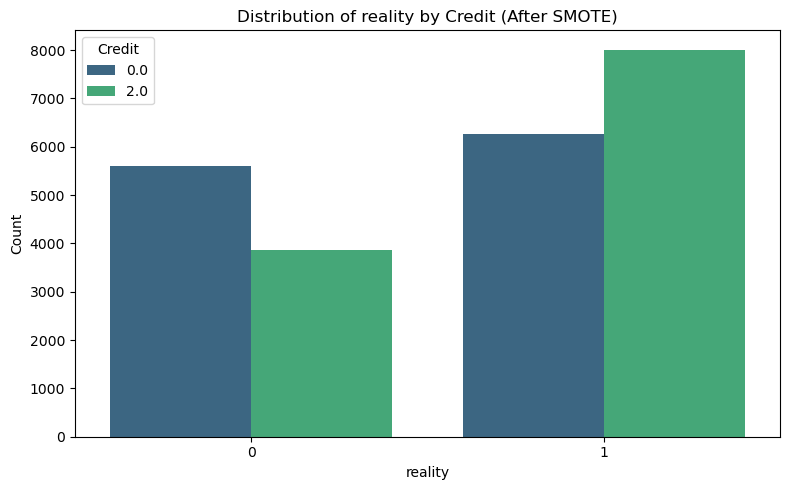

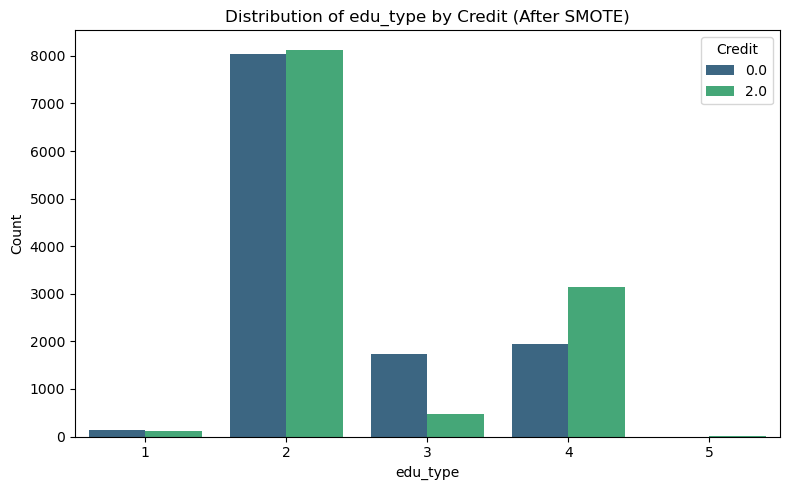

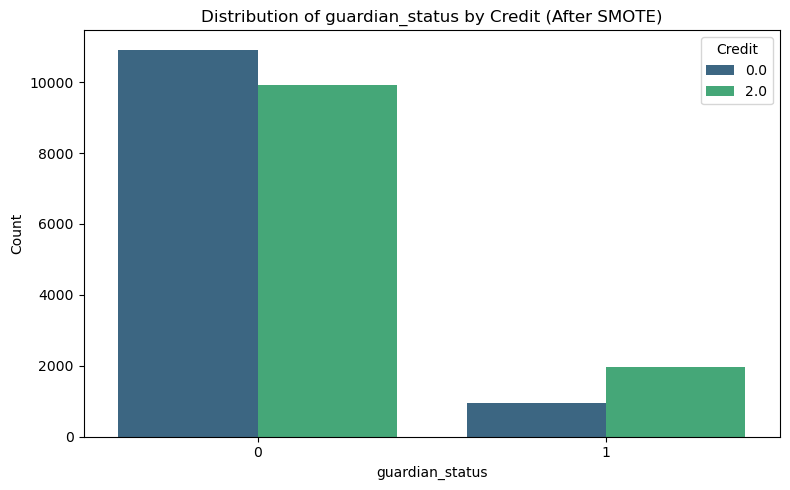

In [10]:
# 범주형 변수 목록
categorical_columns = ['gender', 'car', 'reality', 'edu_type', 'guardian_status']

# SMOTE로 생성된 데이터를 DataFrame으로 변환
X_train_smote_df = pd.DataFrame(X_train_smote, columns=X_train.columns)
y_train_smote_df = pd.Series(y_train_smote, name='credit')

# SMOTE 데이터 병합
smote_balanced_df = pd.concat([X_train_smote_df, y_train_smote_df], axis=1)

# 각 범주형 변수에 대해 분포를 시각화
for col in categorical_columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=smote_balanced_df, x=col, hue='credit', palette='viridis')
    plt.title(f"Distribution of {col} by Credit (After SMOTE)")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend(title="Credit")
    plt.tight_layout()
    plt.show()


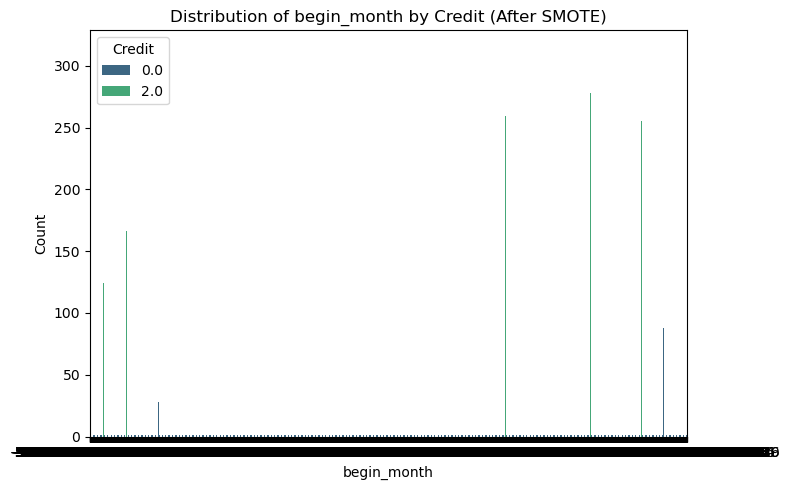

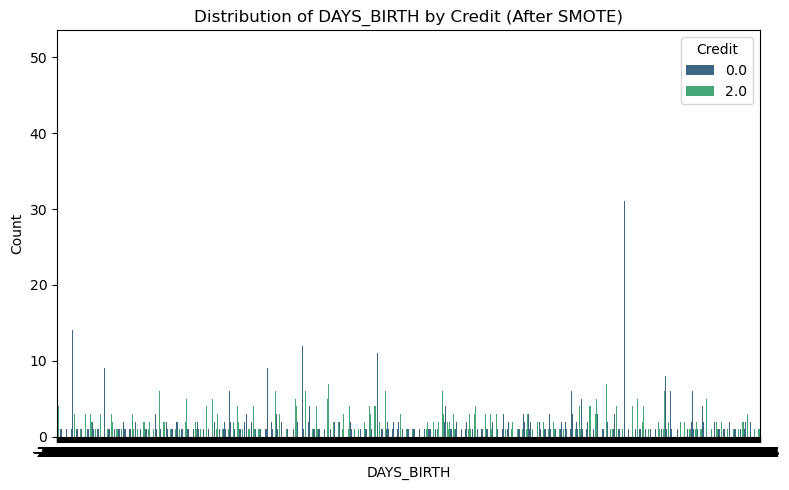

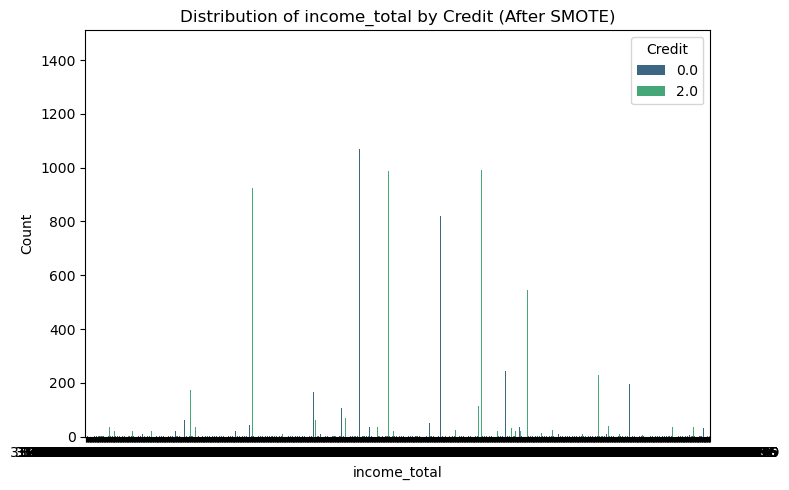

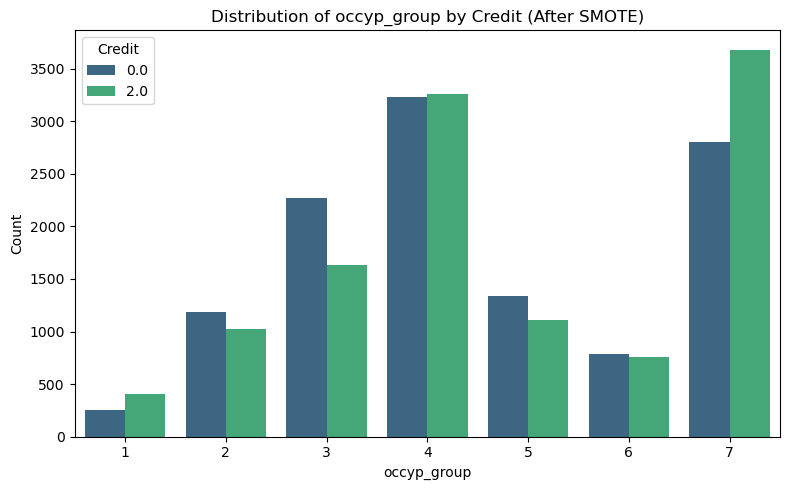

In [14]:
# 범주형 변수 목록
categorical_columns = ['begin_month', 'DAYS_BIRTH', 'income_total', 'occyp_group']

# SMOTE로 생성된 데이터를 DataFrame으로 변환
X_train_smote_df = pd.DataFrame(X_train_smote, columns=X_train.columns)
y_train_smote_df = pd.Series(y_train_smote, name='credit')

# SMOTE 데이터 병합
smote_balanced_df = pd.concat([X_train_smote_df, y_train_smote_df], axis=1)

# 각 범주형 변수에 대해 분포를 시각화
for col in categorical_columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=smote_balanced_df, x=col, hue='credit', palette='viridis')
    plt.title(f"Distribution of {col} by Credit (After SMOTE)")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend(title="Credit")
    plt.tight_layout()
    plt.show()
